In [1]:
import matplotlib.pyplot as plt

from quantumspectra_2024.models import TwoStateModel
from quantumspectra_2024.models.three_state.ThreeStateModel import ThreeStateModel

In [20]:
two_model = TwoStateModel(
    temperature_kelvin=300,
    energy_gap=10745,
    transfer_integral=100,
    mode_basis_sets=[20, 200],
    mode_frequencies=[1400, 100],
    mode_couplings=[0.85, 4.0],
)

three_model = ThreeStateModel(
    temperature_kelvin=300,
    ct_energy_gap=10745,
    le_energy_gap=12358,
    gs_ct_coupling=100,
    ct_le_coupling=0,
    ct_mode_couplings=[0.85, 4.0],
    le_mode_couplings=[0, 0],
    mode_basis_sets=[5, 10],
    mode_frequencies=[1400, 100],
)

In [21]:
two_h = two_model.get_hamiltonian()
three_h = three_model.get_hamiltonian()

two_matrix = two_h.get_matrix()
three_matrix = three_h.get_matrix()

In [22]:
print(np.all(np.equal(two_matrix, three_matrix[:100, :100])))

print(two_matrix.shape)
print(three_matrix.shape)

ValueError: operands could not be broadcast together with shapes (8000,8000) (100,100) 

In [23]:
import numpy as np

two_matrix_np = np.array(two_matrix)
three_matrix_np = np.array(three_matrix)

In [24]:
two_vals, two_vects = np.linalg.eigh(two_matrix_np)
three_vals, three_vects = np.linalg.eigh(three_matrix_np)

percentage: 0.06666666666666667


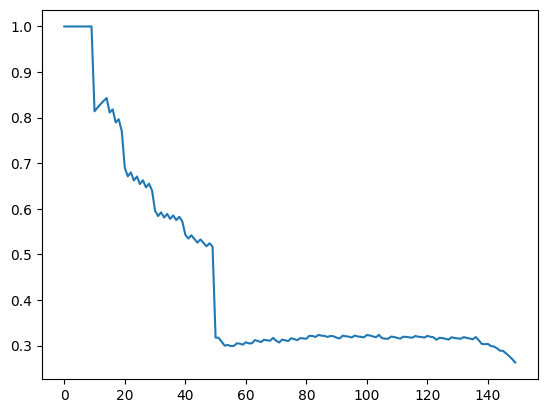

In [25]:
nums = []
vals = []

count_close = 0

for idx, (two_val, three_val) in enumerate(zip(two_vals, three_vals)):
    nums.append(idx)
    vals.append(two_val / three_val)
    if abs(two_val - three_val) < 1e-1:
        count_close += 1

plt.plot(nums, vals)
print("percentage:", count_close / len(nums))

In [26]:
# trying to manually calculate peaks

ct_peak_energies = np.array([])
ct_peak_intensities = np.array([])

le_peak_energies = np.array([])
le_peak_intensities = np.array([])

third_size = three_matrix.shape[0] // 3

for gs_idx in range(third_size):
    gs_energy = three_vals[gs_idx]
    gs_vector = three_vects[:, gs_idx]

    for ct_idx in range(third_size, 2 * third_size):
        ct_energy = three_vals[ct_idx]
        ct_vector = three_vects[:, ct_idx]

        energy = ct_energy - gs_energy
        intensity = np.dot(gs_vector, ct_vector) ** 2

        ct_peak_energies = np.append(ct_peak_energies, energy)
        ct_peak_intensities = np.append(ct_peak_intensities, intensity)

    for le_idx in range(2 * third_size, 3 * third_size):
        le_energy = three_vals[le_idx]
        le_vector = three_vects[:, le_idx]

        energy = le_energy - gs_energy
        intensity = np.dot(gs_vector, le_vector) ** 2

        le_peak_energies = np.append(le_peak_energies, energy)
        le_peak_intensities = np.append(le_peak_intensities, intensity)

    break

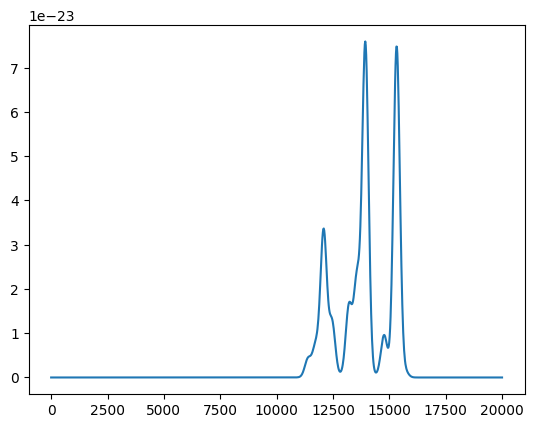

In [27]:
from quantumspectra_2024.models.two_state.TwoStateComputation import (
    filter_peaks,
    broaden_peaks,
)

sample_points = np.linspace(0, 20000, 1000)
ct_peak_intensities = broaden_peaks(
    sample_points, ct_peak_energies, ct_peak_intensities, 200
)

plt.plot(sample_points, ct_peak_intensities)
plt.show()

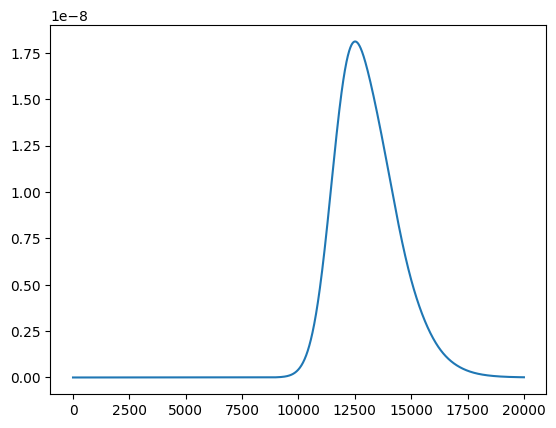

In [28]:
two_abs = two_model.get_absorption()
plt.plot(two_abs.energies, two_abs.intensities)